<a href="https://colab.research.google.com/github/renatanegreiross/Sprint1_ML_MVP_RenataRNAlcantara/blob/main/MVP_ML_Analytics_RenataR_N_Alcantara_2026_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Renata Rocha de Negreiros Alcântara_  
**Matrícula:** _4052026000390_  
**Data:** _04/07/2026_  
**Dataset:** _AI4I 2020 Predictive Maintenance Dataset. Link: https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset_  
**Tipo de problema:** _Classificação_  




# 1. Definição do problema

**Descrição do problema**

Falhas inesperadas em máquinas industriais podem causar paradas não planejadas, gerando perdas de produtividade, aumento com custos de manutenção corretiva e queda de eficiência.

**Contexto do problema**

A manutenção de equipamentos é uma atividade crítica em ambientes industriais, pois a indisponibilidade de máquinas pode impactar diretamente a produtividade e os custos da operação. A identificação antecipada de possíveis falhas permite que ações preventivas sejam realizadas antes da ocorrência de interrupções no processo produtivo.

**Tipo de análise realizada**

Este projeto consiste em uma tarefa de classificação binária. O modelo deverá prever se uma máquina está propensa a falhar com base em variáveis operacionais e de desgaste. As previsões podem auxiliar na tomada de decisão sobre a necessidade de inspeções ou manutenções preventivas.

**Público alvo**

Os principais interessados nessa solução são equipes de manutenção industrial, engenheiros de confiabilidade e gestores de operações.

**Relevância do problema**

A previsão antecipada de falhas pode contribuir para a redução de custos com manutenção corretiva, diminuição de paradas não planejadas, aumento da disponibilidade dos equipamentos e melhoria da eficiência operacional.



## 1.1 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever falhas em máquinas industriais a partir de variáveis de processo, desgaste e condições operacionais, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.



## 1.2 Tipo de problema

**Tipo escolhido:** classificação.

**Justificativa:** o objetivo do problema é prever se uma determinada máquina vai falhar, retornando o resultado 1 em caso positivo ou 0 em caso negativo. Por isso, se enquandra em um problema de Classificação Binária.

## 1.3 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. As variáveis operacionais da máquina (temperatura, velocidade de rotação, torque e desgaste da ferramenta) possuem relação com a ocorrência de falhas.
2. Modelos de Machine Learning serão capazes de prever falhas com melhor desempenho do que uma abordagem que sempre prevê a classe mais frequente (não falha).

**Critérios de sucesso:**
- Métrica principal: Recall.
- Resultado mínimo esperado: obter Recall superior ao modelo baseline.
- Restrição prática: O modelo deve ser treinado utilizando apenas os atributos disponíveis no dataset, sem necessidade de coleta adicional de dados.





# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção contém:
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade.

Observação: Embora este trabalho trate de um problema de classificação, foram mantidas as importações e estruturas referentes a outros tipos de problemas por fazerem parte do template utilizado. Esses trechos não são executados neste estudo, mas foram preservados para manter a estrutura original do notebook.



In [ ]:
# === Setup básico e reprodutibilidade ===

# Bibliotecas
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score, precision_score, recall_score #Mudança: acrescimo dessas métricas
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

# Seed fixa para reprodutibilidade
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)



Python: 3.12.13
Seed: 42


## 2.1 Funções auxiliares

Nesta etapa, são definidas funções auxiliares para padronizar a avaliação dos modelos treinados. Para problemas de classificação, são calculadas as métricas de acurácia, precisão, recall, F1-score ponderado e ROC-AUC, permitindo analisar o desempenho dos modelos sob diferentes perspectivas e compará-los de forma consistente. Também é definida uma função para organizar os resultados em formato de tabela, facilitando sua visualização e análise.


In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""

    # Cria um dicionário para armazenar as métricas do modelo
    results = {
        "accuracy": accuracy_score(y_true, y_pred), # acurácia: proporção de previsões corretas
        "precision": precision_score(y_true, y_pred, zero_division=0), # Mudança: adição dessa métrica. Obs.: o zero_division é para não dar erro se a previsão for só da classe 0
        "recall": recall_score(y_true, y_pred, zero_division=0), # # Mudança: adição dessa métrica
        "f1_weighted": f1_score(y_true, y_pred, average="weighted") # F1-score ponderado, considerando o peso de cada classe
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        # Verifica se as probabilidades foram fornecidas
        # e se existem duas colunas, uma para cada classe: 0 e 1
        if proba is not None and proba.shape[1] == 2:
            # Calcula o ROC-AUC usando a probabilidade da classe 1
            # No caso do dataset, classe 1 = ocorrência de falha
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            # Caso não existam probabilidades adequadas, registra valor ausente
            results["roc_auc"] = np.nan
    # Se ocorrer algum erro no cálculo do ROC-AUC, registra valor ausente
    except Exception:
        results["roc_auc"] = np.nan

    # Retorna o dicionário com as métricas calculadas
    return results

# Não se aplica a esse trabalho, mas mantendo o código do template
def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T # O .T transpõe a tabela, deixando os modelos nas linhas


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Abaixo são apresentados detalhes da base de dados escolhida:
- **Nome do dataset:** AI4I 2020 Predictive Maintenance Dataset;
- **Link da fonte:** https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset
- **Por que esse dataset foi escolhido:** o dataset representa um problema realista de manutenção preditiva, e que pode ser replicado a outros contextos industriais. Além disso, para quem é iniciante no tema de Machine learning, a base é de fácil entendimento e não demanda tratamentos complexos.

- **Há questões de ética, privacidade, confidencialidade ou licença?** Não. O dataset é público, disponibilizado para fins de pesquisa e ensino, e não contém informações pessoais ou sensíveis.




## 3.2 Carga dos dados
O dataset foi baixado do repositório UCI Machine Learning Repository e carregado em repositório público no GitHub.

In [ ]:
# === Carga dos dados ===

url = "https://raw.githubusercontent.com/renatanegreiross/Sprint1_ML_MVP_RenataRNAlcantara/refs/heads/main/ai4i2020.csv"
df = pd.read_csv(url)
print(df.shape) #mostra a quantidade de linhas e colunas da tabela
df.head()


(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3.3 Visão geral do dataset

O dataset possui as seguintes características, conforme demonstradas no código a seguir:

**Quantidade de linhas e colunas**

10.000 linhas e 14 coluna.

**Tipos dos atributos**

Os tipos das 14 colunas estão distribuídos da seguinte forma:
- 9 colunas com dados inteiros;
- 2 colunas com dados de texto;
- 3 colunas com valores decimais.

**Valores ausentes**

Não existem valores ausentes no dataset.

**Duplicatas**

Não existem linhas duplicadas no dataset.

**Possíveis colunas de ID, data ou variáveis que não devem entrar no modelo**

As colunas UDI e Product ID foram identificadas como variáveis de identificação e, por isso, não serão utilizadas na modelagem, pois não representam características relacionadas ao comportamento da máquina. Também serão desconsideradas as variáveis TWF, HDF, PWF, OSF e RNF, uma vez que indicam os tipos específicos de falha que compõem o target (Machine failure). Sua utilização como preditoras poderia introduzir vazamento de informação (data leakage), fornecendo ao modelo informações que, na prática, não estariam disponíveis no momento da previsão.

**Descrição do target**

O target é a variável Machine failure, que indica a ocorrência (1) ou não ocorrência (0) de falha na máquina. Trata-se de um problema de classificação binária supervisionada.

In [ ]:

# Quantidade de linhas e colunas
print("Formato do dataset:", df.shape)

# Tipos dos atributos
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))


Formato do dataset: (10000, 14)

Tipos de dados:


,tipo
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64


In [ ]:
# Valores ausentes
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [ ]:
# Duplicatas
print("\nDuplicatas:", df.duplicated().sum())


Duplicatas: 0


In [ ]:
#Exibição de 5 linhas aleatórioas da base
display(df.sample(5, random_state=SEED))

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
6252,6253,L53432,L,300.8,310.3,1538,36.1,198,0,0,0,0,0,0
4684,4685,M19544,M,303.6,311.8,1421,44.8,101,1,0,0,0,0,0
1731,1732,M16591,M,298.3,307.9,1485,42.0,117,0,0,0,0,0,0
4742,4743,L51922,L,303.3,311.3,1592,33.7,14,0,0,0,0,0,0
4521,4522,L51701,L,302.4,310.4,1865,23.9,129,0,0,0,0,0,0


## 3.4 Dicionário de dados

A seguir é apresentado o dicionário de dados do dataset de Manutenção Preditiva.

| Coluna                  | Tipo       | Descrição                               | Será usada no modelo? | Observações                                   |
| ----------------------- | ---------- | --------------------------------------- | --------------------- | --------------------------------------------- |
| UDI                     | numérica   | Identificador único do registro         | não                   | Coluna de ID, não agrega informação preditiva |
| Product ID              | texto      | Identificador do produto                | não                   | ID do produto, também não agrega informação preditiva       |
| Type                    | categórica  | Tipo/qualidade do produto: L, M ou H    | sim                   | Variável categórica de entrada, em que L=Low (baixa qualidade do produto), M=Medium (Média) e H=Hight (Alta)                |
| Air temperature [K]     | numérica   | Temperatura do ar em Kelvin             | sim                   | Variável operacional                          |
| Process temperature [K] | numérica   | Temperatura do processo em Kelvin       | sim                   | Variável operacional                          |
| Rotational speed [rpm]  | numérica   | Velocidade de rotação da máquina        | sim                   | Variável operacional                          |
| Torque [Nm]             | numérica   | Torque aplicado no processo             | sim                   | Variável operacional                          |
| Tool wear [min]         | numérica   | Tempo de desgaste da ferramenta         | sim                   | Variável operacional                          |
| TWF                     | categórica    | Indica falha por desgaste da ferramenta | não                   | Pode causar vazamento de informação           |
| HDF                     | categórica    | Indica falha por dissipação de calor    | não                   | Pode causar vazamento de informação           |
| PWF                     | categórica    | Indica falha de potência                | não                   | Pode causar vazamento de informação           |
| OSF                     | categórica   | Indica falha por sobrecarga             | não                   | Pode causar vazamento de informação           |
| RNF                     | categórica    | Indica falha aleatória                  | não                   | Pode causar vazamento de informação           |
| Machine failure         | Target       | Indica se houve falha na máquina        | Target                  | Classe prevista: 0 = sem falha, 1 = com falha |



# 4. Análise exploratória dos dados

 No código a seguir serão analisadas:

- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

Distribuição do target:


,contagem
Machine failure,
0,9661
1,339


,percentual
Machine failure,
0,96.61
1,3.39


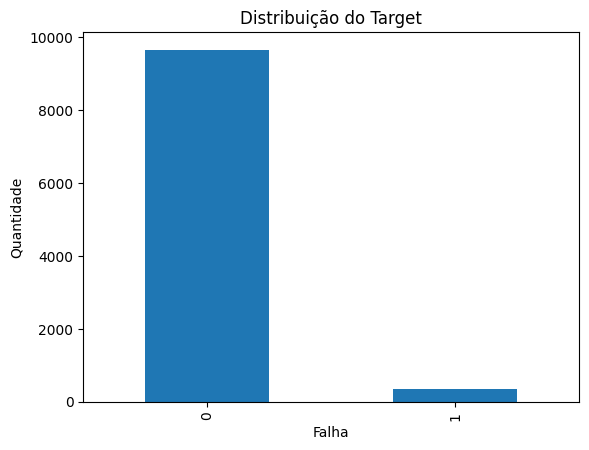

In [ ]:
# Distribuição do target
TARGET = "Machine failure"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))

# Gráfico de Barras para Ilustrar tabela
df[TARGET].value_counts().plot(kind="bar")
plt.title(f"Distribuição do Target")
plt.xlabel("Falha")
plt.ylabel("Quantidade")
plt.show()


Nas tabelas acima, verifica-se um forte desbalanceamento do target, com predominância da classe 0 (máquinas sem falha), comportamento esperado para problemas de manutenção preditiva. Esse desbalanceamento torna a acurácia insuficiente como única métrica de avaliação, sendo necessário considerar também precisão, recall, F1-score e ROC-AUC. Em especial, o recall será acompanhado com atenção por representar a capacidade do modelo de identificar máquinas que realmente apresentarão falha, aspecto de grande importância para o problema em estudo.

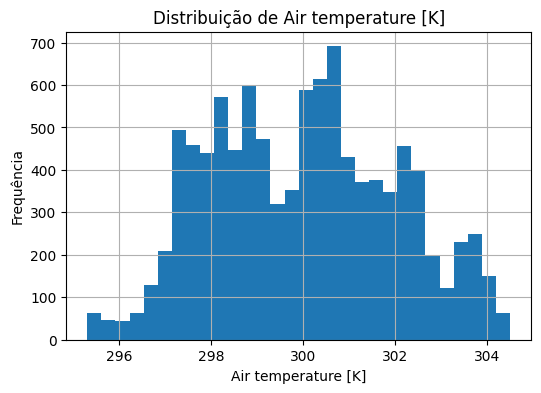

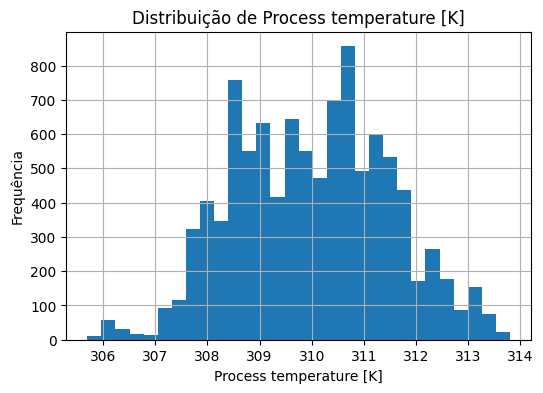

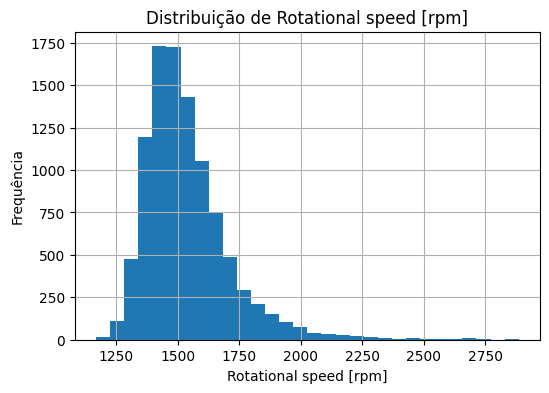

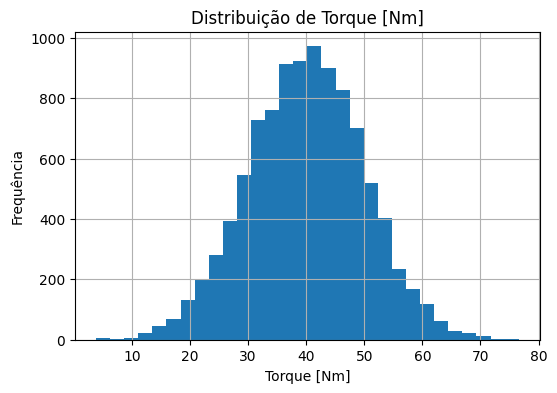

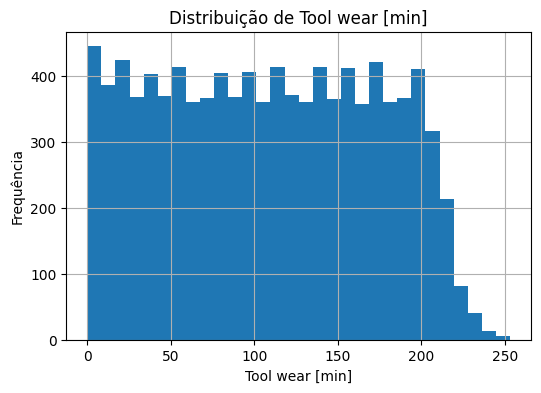

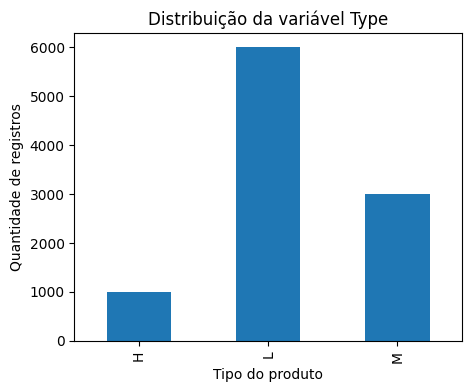

In [ ]:
# ============================================================
# Distribuição de variáveis importantes
# ============================================================

# Seleciona as principais variáveis numéricas do dataset, que representam
# características operacionais da máquina
important_numeric = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Gera um histograma para cada variável numérica.
# O objetivo é observar o formato da distribuição,
# possíveis assimetrias e outliers.
for col in important_numeric:
    plt.figure(figsize=(6,4))

    df[col].hist(bins=30)

    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")

    plt.show()


# ============================================================
# Distribuição da variável categórica
# ============================================================

# A variável "Type" representa a categoria de qualidade do produto
# (L = Low, M = Medium, H = High).
# O gráfico permite visualizar a quantidade de registros em cada categoria.

plt.figure(figsize=(5,4))

df["Type"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribuição da variável Type")
plt.xlabel("Tipo do produto")
plt.ylabel("Quantidade de registros")

plt.show()


De modo geral, as principais variáveis numéricas apresentam distribuições concentradas em torno de valores centrais, sem evidências de outliers aparentes nos histogramas. A variável Tool wear (desgaste da ferramenta) difere das demais por apresentar uma distribuição com múltiplos picos ao longo de sua faixa de valores, indicando maior variabilidade em relação às demais características analisadas. Quanto à variável categórica Type, observa-se a predominância da categoria L, seguida pelas categorias M e H.

Essas características indicam que as variáveis apresentam comportamento consistente para utilização na modelagem. A influência de cada uma delas na ocorrência de falhas será avaliada nas análises de relação entre as variáveis e o target.

<Figure size 600x400 with 0 Axes>

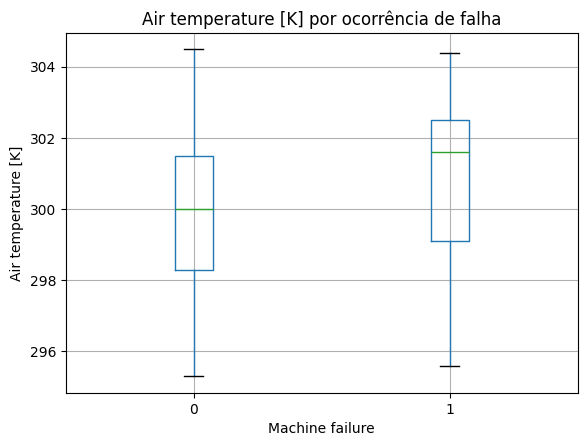

<Figure size 600x400 with 0 Axes>

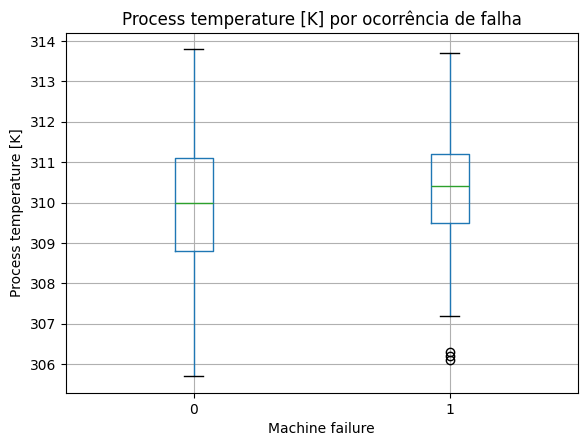

<Figure size 600x400 with 0 Axes>

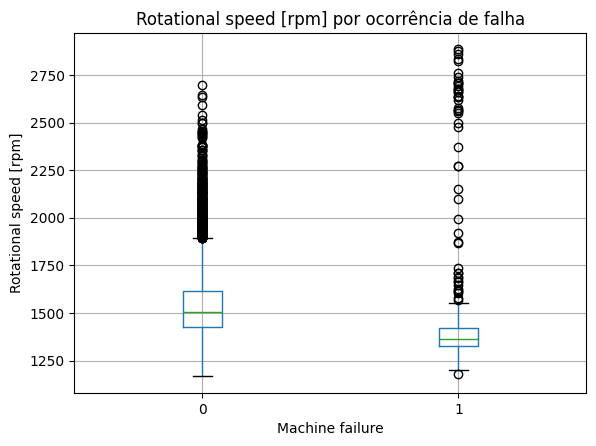

<Figure size 600x400 with 0 Axes>

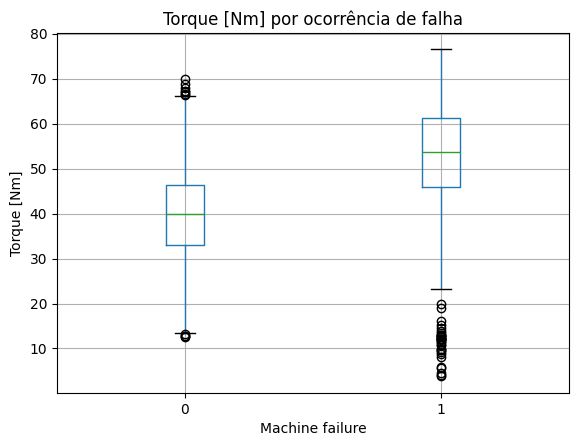

<Figure size 600x400 with 0 Axes>

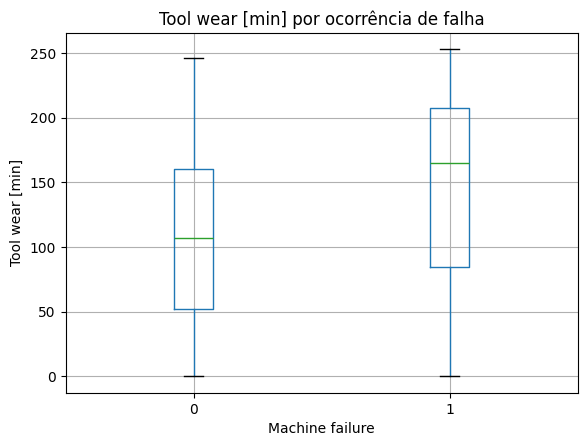

In [ ]:
# ============================================================
# Relação entre variáveis importantes e o target
# ============================================================

# Boxplots para comparar a distribuição das variáveis numéricas
# entre máquinas sem falha (0) e com falha (1).
for col in important_numeric:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by=TARGET)

    plt.title(f"{col} por ocorrência de falha")
    plt.suptitle("")
    plt.xlabel("Machine failure")
    plt.ylabel(col)

    plt.show()

De modo geral, os boxplots permitem comparar a distribuição das principais variáveis entre máquinas com e sem falha. Observam-se diferenças na posição da mediana e na dispersão de algumas variáveis, indicando que determinadas características podem estar associadas à ocorrência de falhas. Também são identificados alguns valores outliers, os quais foram mantidos para a etapa de modelagem, uma vez que podem representar condições reais de operação e não há evidências, nesta análise, de que correspondam a erros de medição.

Machine failure,0,1
Type,,
H,97.91,2.09
L,96.08,3.92
M,97.23,2.77


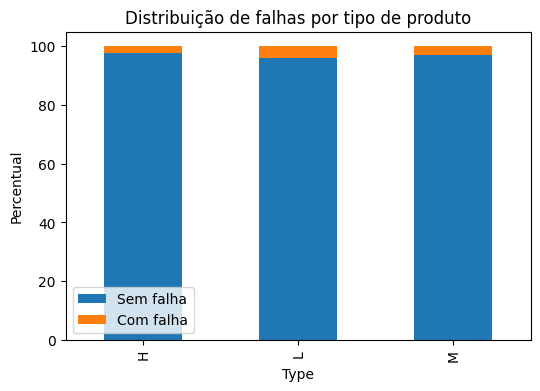

In [ ]:
# ============================================================
# Relação entre variável categórica e target
# ============================================================

# Tabela percentual de falhas por tipo de produto
falha_por_tipo = pd.crosstab(
    df["Type"],
    df[TARGET],
    normalize="index"
) * 100

display(falha_por_tipo.round(2))

# Gráfico de barras empilhadas
falha_por_tipo.plot(kind="bar", stacked=True, figsize=(6,4))

plt.title("Distribuição de falhas por tipo de produto")
plt.xlabel("Type")
plt.ylabel("Percentual")
plt.legend(["Sem falha", "Com falha"])
plt.show()

A distribuição de falhas é semelhante entre os três tipos de produto, com predominância de registros sem falha em todas as categorias. Entretanto, observa-se que produtos do tipo L apresentam a maior proporção de falhas (3,92%), enquanto os tipos M e H apresentam percentuais menores (2,77% e 2,09%, respectivamente). Esses resultados sugerem que o tipo de produto pode estar relacionado à ocorrência de falhas e, portanto, representar uma variável relevante para a modelagem preditiva.

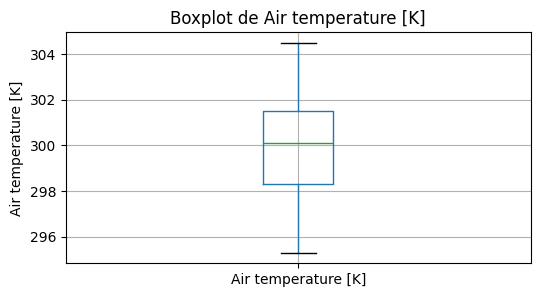

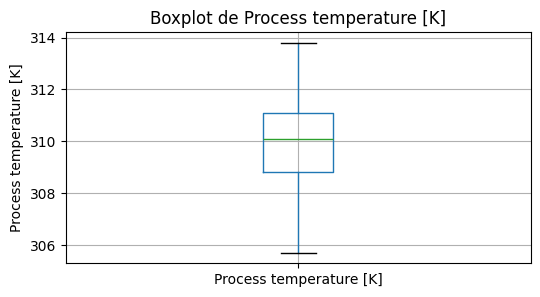

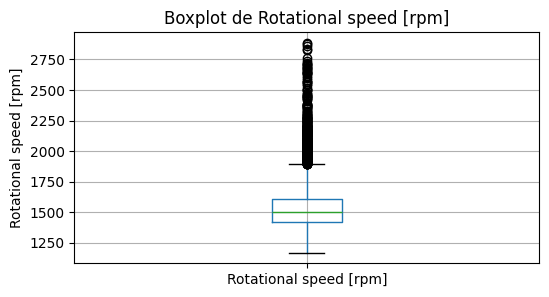

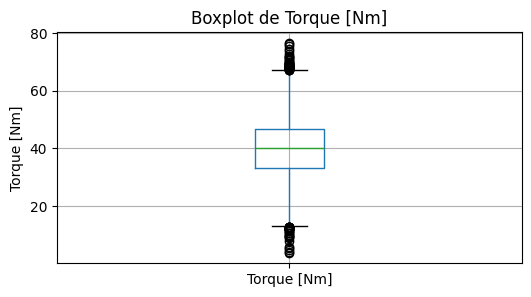

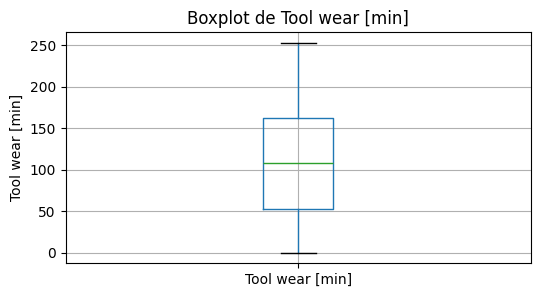

In [ ]:
# ============================================================
# Identificação de outliers nas variáveis numéricas
# ============================================================

for col in important_numeric:
    plt.figure(figsize=(6,3))
    df.boxplot(column=col)

    plt.title(f"Boxplot de {col}")
    plt.ylabel(col)

    plt.show()

Os boxplots mostram que as variáveis Air temperature e Process temperature não apresentam valores considerados outliers, indicando distribuições relativamente homogêneas e sem observações extremas. Em contrapartida, as variáveis Rotational speed e Torque apresentam diversos valores fora dos limites dos quartis, sugerindo a existência de observações extremas nessas características operacionais. Já a variável Tool wear não apresenta outliers, embora exiba maior dispersão dos dados em comparação às variáveis de temperatura.

A presença de outliers em Rotational speed e Torque não implica, necessariamente, problemas de qualidade dos dados, pois esses valores podem representar condições reais de operação da máquina e estar associados à ocorrência de falhas. Dessa forma, os outliers foram mantidos na base de dados, uma vez que não há indícios de erros de medição e sua remoção poderia eliminar informações potencialmente relevantes para a modelagem.

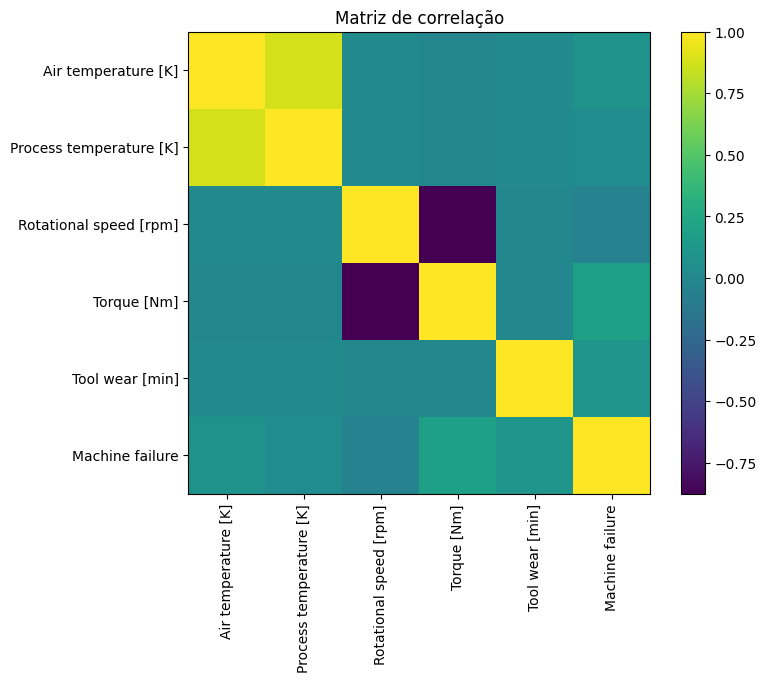

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.00,0.88,0.02,-0.01,0.01,0.08
Process temperature [K],0.88,1.00,0.02,-0.01,0.01,0.04
Rotational speed [rpm],0.02,0.02,1.00,-0.88,0.00,-0.04
Torque [Nm],-0.01,-0.01,-0.88,1.00,-0.00,0.19
Tool wear [min],0.01,0.01,0.00,-0.00,1.00,0.11
Machine failure,0.08,0.04,-0.04,0.19,0.11,1.00


In [ ]:
# ============================================================
# Padrões relevantes: matriz de correlação
# ============================================================

corr_cols = important_numeric + [TARGET]

corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Matriz de correlação")
plt.show()

display(corr.round(2))

A matriz de correlação indica que a maioria das variáveis apresenta correlação linear fraca com o target (Machine failure), sugerindo que a ocorrência de falhas depende da combinação de múltiplos fatores, e não de uma única característica isolada. A maior correlação com o target foi observada para o Torque (0,19), seguida pela Tool wear (0,11), enquanto as variáveis de temperatura apresentam correlação bastante baixa.

Destaca-se também a forte correlação positiva entre Air temperature e Process temperature (0,88), indicando que ambas tendem a variar conjuntamente. Além disso, observa-se uma forte correlação negativa entre o Rotational speed e o Torque (-0,88), evidenciando uma relação inversa entre essas características operacionais.

## 4.1 Síntese da análise exploratória

A análise exploratória permitiu compreender as principais características do conjunto de dados e identificar aspectos relevantes que podem ser úteis nas próximas etapas. A seguir, são apresentados os principais achados da análise.

**O target está balanceado?**

O target (Machine failure) apresenta forte desbalanceamento, com predominância de registros sem falha. Esse comportamento indica que métricas como precisão, recall e F1-score serão mais adequadas do que apenas a acurácia para avaliar o desempenho dos modelos.

**Existem valores ausentes relevantes?**

Não foram identificados valores ausentes no conjunto de dados, não sendo necessário realizar tratamentos relacionados à imputação ou remoção de registros por esse motivo.

**Há variáveis com escalas muito diferentes?**

Sim. As variáveis numéricas apresentam ordens de grandeza distintas. As temperaturas assumem valores próximos de 300 K, o torque concentra-se em torno de dezenas de N·m, o desgaste da ferramenta varia de 0 a aproximadamente 250 minutos e a velocidade de rotação assume valores próximos de 1500 rpm. Essas diferenças de escala poderão exigir a aplicação de técnicas de padronização ou normalização, dependendo do algoritmo de Machine Learning utilizado.

**Há categorias raras?**

Não. A variável categórica Type possui apenas três categorias (L, M e H), todas representadas por quantidade significativa de registros.

**Existem padrões que sugerem quais modelos podem funcionar melhor?**

Sim. A matriz de correlação mostrou que as variáveis apresentam baixa correlação linear individual com o target, sugerindo que a ocorrência de falhas depende da interação entre múltiplas características operacionais. Além disso, foram observadas fortes correlações entre Air temperature e Process temperature (0,88), bem como entre Rotational speed e Torque (-0,88), indicando relações importantes entre essas variáveis. Esses resultados reforçam a importância de comparar uma abordagem linear, representada pela Regressão Logística, com uma abordagem baseada em árvores, representada pelo Random Forest, que é capaz de capturar relações não lineares e interações entre os atributos.

**Algum resultado da EDA mudou a estratégia de pré-processamento ou modelagem?**

Sim. A EDA mostrou que o target apresenta forte desbalanceamento, indicando que a acurácia, isoladamente, não seria suficiente para avaliar o desempenho dos modelos. Por esse motivo, a avaliação dos modelos passou a considerar, além da acurácia, métricas como precisão, recall, F1-score e ROC-AUC. Também foram observadas diferenças de escala entre as variáveis numéricas e a presença de uma variável categórica, justificando a aplicação de padronização e codificação no pipeline de pré-processamento. Por fim, a baixa correlação individual entre os atributos e o target reforçou a comparação entre uma abordagem linear (Regressão Logística) e uma abordagem capaz de capturar relações não lineares (Random Forest).





# 5. Preparação dos dados e divisão treino/teste

Nesta etapa será definida a estrutura utilizada para a modelagem preditiva. Inicialmente, será definido o target (Machine failure), caracterizando o problema como uma classificação binária, cujo objetivo é prever se uma máquina apresentará ou não falha.

Em seguida, serão definidas as variáveis de entrada (features), removendo colunas que não devem ser utilizadas na modelagem. As colunas UDI e Product ID serão excluídas por representarem apenas identificadores, enquanto as colunas TWF, HDF, PWF, OSF e RNF serão removidas por representarem tipos específicos de falha, podendo introduzir vazamento de informação (data leakage) em relação ao target.

Após essa definição, os dados serão divididos em conjuntos de treino e teste utilizando a estratégia holdout, destinando 80% dos registros para treinamento e 20% para avaliação final do modelo. Como o target apresenta desbalanceamento entre as classes, a divisão será realizada de forma estratificada, preservando a proporção de máquinas com e sem falha em ambos os conjuntos. Essa abordagem permite reservar um conjunto independente para avaliar o desempenho final dos modelos, enquanto a validação cruzada estratificada será empregada posteriormente, durante a otimização de hiperparâmetros, utilizando apenas os dados de treinamento para selecionar a melhor configuração do modelo.

In [ ]:
# === Configuração do problema ===

TARGET = "Machine failure"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = ["UDI", "Product ID"]  # Colunas que representam apenas identificadores
DATE_COLUMN = None

# Colunas removidas para evitar vazamento de informação,
# pois são tipos específicos de falha e que definem diretamente o Target
DROP_COLUMNS = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# Verifica se o target foi definido corretamente
if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

# Cria um conjunto contendo todas as colunas que deverão ser excluídas
# da entrada do modelo (identificadores e colunas removidas).
columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)

# Adiciona também a variável Target às colunas excluídas,
# pois ela será prevista pelo modelo e não utilizada como entrada.
if TARGET is not None:
    columns_to_exclude.add(TARGET)

# Cria a lista de features, contendo apenas as variáveis
# que serão utilizadas para treinamento.
features = [c for c in df.columns if c not in columns_to_exclude]

# Exibe um resumo da configuração escolhida.
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: Machine failure
Número de features: 6
Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [ ]:
# === Divisão dos dados ===

# X contém as colunas que serão usadas como entrada do modelo.
# y contém a coluna que o modelo deverá prever.
if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

# Como se trata de um problema de classificação com target desbalanceado,
# utiliza-se a estratificação para manter a proporção de falhas e não falhas
# tanto no conjunto de treino quanto no conjunto de teste.
    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (8000, 6) | Teste: (2000, 6)


## 5.1 Justificativa da divisão

**Por que usar holdout?**

Essa abordagem é adequada para este trabalho por ser simples e compatível com o tamanho do dataset (10.000 registros). Além disso, permite reservar um conjunto de teste independente para avaliar o desempenho final do modelo. Posteriormente, durante a otimização dos hiperparâmetros, foi utilizada validação cruzada estratificada apenas sobre o conjunto de treinamento, proporcionando uma estimativa mais robusta do desempenho das diferentes configurações.

**A proporção treino/teste faz sentido para o tamanho do dataset?**

Sim. Foi adotada a divisão de 80% para treinamento e 20% para teste. Com 10.000 registros disponíveis, essa proporção fornece uma quantidade suficiente de exemplos para o treinamento dos modelos, ao mesmo tempo em que mantém um conjunto de teste representativo para avaliar sua capacidade de generalização.

**Foi necessário estratificar as classes?**

Sim. Como o target apresenta desbalanceamento entre as classes (há muito mais registros sem falha do que com falha), foi utilizada a estratificação (stratify) durante a divisão dos dados. Dessa forma, a proporção entre registros com e sem falha é mantida tanto no conjunto de treinamento quanto no conjunto de teste, tornando a avaliação mais representativa.

**Como a divisão evita vazamento de dados?**

O vazamento de dados foi evitado pela combinação de duas medidas. Primeiramente, as colunas TWF, HDF, PWF, OSF e RNF foram removidas antes da modelagem, pois representam tipos específicos de falha diretamente relacionados ao target (Machine failure) e poderiam fornecer ao modelo informações que não estariam disponíveis no momento da previsão. Além disso, a divisão entre treino e teste foi realizada antes do treinamento e de qualquer ajuste dos modelos, garantindo que o conjunto de teste permanecesse totalmente independente durante o desenvolvimento e a otimização.


# 6. Pré-processamento e pipeline

A sequência utilizada foi a seguinte:

**1. Imputação de valores ausentes**

Apesar de não existirem valores ausentes no dataset, conforme demonstrado no item 3.3, o código original do modelo do MVP foi mantido.

**2. Normalização ou padronização**

As variáveis numéricas foram padronizadas utilizando o StandardScaler, que transforma cada variável para uma escala com média próxima de zero e desvio padrão igual a um.

**3. Encoding de variáveis categóricas**

A variável categórica Type foi convertida para formato numérico utilizando OneHotEncoder, que cria uma coluna binária para cada categoria existente.

**4. Seleção de atributos**

Embora tenha sido avaliada a correlação entre as variáveis durante a análise exploratória, optou-se por manter todas as variáveis preditoras por serem consideradas relevantes para a predição de falhas.




In [ ]:
# Identificação automática simples de colunas numéricas e categóricas.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist() # seleciona as colunas numéricas
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist() # seleciona as colunas categóricas

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

# Cria o pipeline de tratamento das variáveis numéricas.
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # Imputação por meio de mediana (não aplicável a esse dataset)
    ("scaler", StandardScaler()) # Padroniza as variáveis numéricas, colocando-as em uma escala comparável.
])

# Cria o pipeline de tratamento das variáveis categóricas
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # Preenche possíveis valores ausentes usando a categoria mais frequente (moda).

    # Transforma categorias em variáveis numéricas binárias.
    # O parâmetro handle_unknown="ignore" evita erro se surgir uma categoria nova no teste
     ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combina os tratamentos numérico e categórico em um único pré-processador.
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Colunas categóricas: ['Type']


## 6.1 Decisões de pré-processamento

**Por que os dados foram padronizados?**

As variáveis numéricas do dataset apresentam escalas diferentes. Enquanto as temperaturas estão na ordem de centenas de Kelvin, a velocidade de rotação é medida em milhares de rpm, o torque em dezenas de Nm e o desgaste da ferramenta em minutos. Por isso, utilizou-se o StandardScaler para colocar todas as variáveis em uma escala comparável, evitando que atributos com valores numéricos maiores exerçam influência desproporcional durante o treinamento.

**Quais variáveis foram removidas e por quê?**

Nessa etapa não foi necessário remover variáveis.

**Foram criadas novas variáveis?**

Não foi necessário utilizar engenharia de atributos neste trabalho.




# 7. Baseline e modelos candidatos

Para avaliar se os algoritmos de Machine Learning realmente aprendem padrões associados às falhas das máquinas, foi definido inicialmente um modelo de referência (baseline) e, em seguida, selecionados dois modelos candidatos para comparação.

O baseline utiliza uma estratégia simples, servindo como ponto de partida para verificar se os modelos supervisionados apresentam ganho real de desempenho. Em seguida, foram utilizados os algoritmos Regressão Logística e Random Forest, ambos implementados em pipelines contendo as mesmas etapas de pré-processamento, garantindo uma comparação justa entre os modelos.

Os resultados serão comparados por meio de métricas de classificação, permitindo identificar qual abordagem apresenta melhor desempenho para o problema proposto.


In [ ]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED)) # retirado o class_weight="balanced"
        ])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

**O baseline escolhido é coerente?**

Sim. O baseline escolhido foi o DummyClassifier com a estratégia most_frequent, que sempre prevê a classe mais frequente no conjunto de treinamento. Como o dataset apresenta forte desbalanceamento na variável target Machine failure, o baseline escolhido vai apresentar os resultados mais "óbvios" para fins de comparação com os candidatos.

**Os modelos candidatos são adequados ao tipo e tamanho dos dados?**

Sim. A escolha dos modelos foi baseada tanto nas características do problema quanto na análise exploratória realizada anteriormente. Como a matriz de correlação indicou baixa correlação linear individual entre os atributos e o target, além de sugerir possíveis interações entre as variáveis, optou-se por comparar duas abordagens complementares. A Regressão Logística foi escolhida por ser um modelo simples, rápido e de fácil interpretação, permitindo verificar o desempenho de uma abordagem linear. Já o Random Forest foi selecionado por ser capaz de capturar relações não lineares e interações mais complexas entre os atributos. Dessa forma, a comparação permite avaliar qual abordagem se adapta melhor ao comportamento observado nos dados. Além disso, ambos os modelos são adequados ao conjunto de dados de 10.000 registros, apresentando baixo custo computacional para treinamento e avaliação.

**Algum modelo exige escala, encoding ou tratamento específico?**

Sim. A Regressão Logística é sensível à escala das variáveis e requer padronização, enquanto o Random Forest não. Ambos, porém, exigem que variáveis categóricas sejam convertidas para formato numérico por meio de encoding.

**Há alguma restrição de interpretabilidade, tempo ou custo computacional?**

Não. Para este conjunto de dados, tanto a Regressão Logística quanto o Random Forest apresentaram tempo de treinamento e custo computacional reduzidos, sem limitar a execução do experimento. Em relação à interpretabilidade, a Regressão Logística é mais fácil de interpretar, enquanto o Random Forest é menos transparente por combinar múltiplas árvores de decisão. Entretanto, essa diferença não representou uma restrição para o desenvolvimento deste trabalho.

# 8. Treinamento e avaliação inicial

Nesta etapa são treinados o modelo baseline e os modelos candidatos utilizando os dados de treinamento. Em seguida, cada modelo é avaliado no conjunto de teste por meio das métricas de classificação definidas anteriormente, permitindo comparar seu desempenho inicial e o tempo necessário para o treinamento.


In [ ]:
# Cria um dicionário vazio para armazenar as métricas de avaliação de cada modelo
results = {}
# Cria um dicionário vazio para armazenar os modelos já treinados
trained_models = {}

# Verifica se o problema é de classificação ou regressão
if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # =========================
    # Baseline
    # =========================
    t0 = time.time() # Marca o tempo inicial antes do treinamento
    baseline.fit(X_train, y_train) # Treina o modelo baseline usando os dados de treino
    train_time = time.time() - t0 # Calcula o tempo total de treinamento

    y_pred = baseline.predict(X_test)  # Gera as previsões usando os dados de teste

    # Se o problema for de classificação (que é o caso)
    if PROBLEM_TYPE == "classificacao":
        # Verifica se o modelo gera probabilidades.
        # Se gerar, calcula as probabilidades para o teste.
        # Se não gerar, guarda None.
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None # Retorna a probabilidade prevista para cada classe (útil para métricas como ROC-AUC)
        results["baseline"] = evaluate_classification(y_test, y_pred, proba) # Compara os valores reais de teste com as previsões geradas e calcula as métricas de classificação

    #Se for regressão (não se aplica ao problema desse trabalho, mas mantendo o código original)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)

    # Adiciona o tempo de treinamento aos resultados do baseline
    results["baseline"]["train_time_s"] = round(train_time, 3)
    # Armazena o modelo baseline treinado
    trained_models["baseline"] = baseline


    # =========================
    # Modelos candidatos
    # =========================

    # Percorre todos os modelos candidatos definidos anteriormente
    for name, model in candidates.items():
        t0 = time.time() # Marca o tempo inicial antes do treinamento
        model.fit(X_train, y_train) # Treina o modelo candidato com os dados de treino
        train_time = time.time() - t0 # Calcula o tempo total de treinamento

        y_pred = model.predict(X_test) # Faz previsões no conjunto de teste
        # Se o problema for de classificação (que é o caso)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None # Retorna a probabilidade prevista para cada classe (útil para métricas como ROC-AUC)
            results[name] = evaluate_classification(y_test, y_pred, proba) # Compara os valores reais de teste com as previsões geradas e calcula as métricas de classificação

        #Se for regressão (não se aplica ao problema desse trabalho, mas mantendo o código original)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        # Adiciona o tempo de treinamento aos resultados do modelo
        results[name]["train_time_s"] = round(train_time, 3)
        # Armazena o modelo treinado
        trained_models[name] = model

#Não se aplica aqui, mas mantendo o código
elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

#Não se aplica aqui, mas mantendo o código
elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

# Exibe a tabela final com os resultados dos modelos
show_results_table(results)


,accuracy,precision,recall,f1_weighted,roc_auc,train_time_s
baseline,0.9660,0.000000,0.000000,0.949294,0.500000,0.064
LogisticRegression,0.9675,0.636364,0.102941,0.956012,0.899388,0.252
RandomForest,0.9805,0.891892,0.485294,0.977699,0.965283,1.960


## 8.1 Análise dos resultados iniciais

**O modelo superou o baseline?**

Sim. Ambos os modelos candidatos superaram o baseline. Embora a diferença na acurácia seja relativamente pequena (96,60% para 96,75% e 98,05%), as demais métricas evidenciam uma melhora significativa. O baseline não identificou nenhum caso de falha (precision = 0 e recall = 0), além de apresentar ROC-AUC igual a 0,50, equivalente a um classificador sem capacidade discriminatória. A Regressão Logística apresentou melhora nessas métricas, enquanto o Random Forest obteve o melhor desempenho geral, alcançando precision de 0,892, recall de 0,485 e ROC-AUC de 0,965.

**As métricas escolhidas são suficientes para avaliar o problema?**

Sim. As métricas utilizadas são complementares e permitem uma avaliação adequada do problema. Como o conjunto de dados é desbalanceado, a acurácia foi analisada em conjunto com precision, recall, F1-score ponderado e ROC-AUC, proporcionando uma visão mais completa do desempenho dos modelos.

**Algum modelo parece sofrer de underfitting?**

O baseline apresenta fortes indícios de desempenho insuficiente, pois não identificou nenhum caso de falha (recall = 0) e obteve ROC-AUC de 0,50, equivalente a uma classificação aleatória. Já a Regressão Logística e o Random Forest apresentaram desempenho significativamente superior, não havendo evidências de underfitting nesta avaliação inicial.

**O tempo de treinamento é aceitável?**

Sim. Todos os modelos apresentaram tempo de treinamento reduzido para o tamanho do conjunto de dados, tornando sua utilização viável. Embora o Random Forest demande mais tempo de processamento do que a Regressão Logística, essa diferença não representa uma limitação para este trabalho.

**O resultado faz sentido considerando a EDA?**

Sim. Os resultados são compatíveis com a análise exploratória. A EDA mostrou que o conjunto de dados apresenta desbalanceamento entre as classes, o que dificulta a identificação das falhas. Além disso, observou-se que a maior parte das variáveis possui baixa correlação linear com a ocorrência de falhas, sugerindo que esse evento depende da interação entre múltiplas características operacionais, e não de um único atributo. Nesse contexto, o Random Forest apresentou desempenho superior à Regressão Logística, alcançando melhores resultados em acurácia, precisão, recall, F1-score ponderado e ROC-AUC. Isso indica que sua capacidade de capturar relações não lineares e interações entre os atributos foi mais adequada às características do problema.




# 9. Validação e otimização de hiperparâmetros

Nesta etapa, foi realizada uma busca simples de hiperparâmetros para avaliar se uma configuração diferente da padrão poderia melhorar o desempenho do modelo.

**Qual modelo foi otimizado?**

Foi otimizado o modelo Random Forest Classifier, por ter apresentado bom desempenho na etapa anterior e possuir diversos hiperparâmetros que podem influenciar sua capacidade de generalização.

**Quais hiperparâmetros foram testados?**

Foram avaliados os seguintes hiperparâmetros:

- n_estimators: quantidade de árvores da floresta (50 a 249);
- max_depth: profundidade máxima das árvores (2 a 19);
- min_samples_split: número mínimo de amostras necessárias para dividir um nó (2 a 9);
- class_weight: peso atribuído às classes, comparando a configuração padrão com a opção balanced.

**Qual estratégia de validação foi usada?**

Foi utilizada a estratégia RandomizedSearchCV com validação cruzada estratificada em 5 folds (StratifiedKFold), preservando a proporção das classes em cada divisão dos dados.

**Qual métrica guiou a escolha?**

A métrica utilizada foi o recall, pois, neste problema, é importante aumentar a capacidade do modelo de identificar corretamente as máquinas que apresentam falha. Como a classe de falha é minoritária, priorizar o recall ajuda a reduzir a quantidade de falhas reais não detectadas.

**Qual foi a melhor configuração?**

A melhor combinação encontrada foi:

n_estimators = 237;
max_depth = 3;
min_samples_split = 9;
class_weight = balanced.

Essa configuração obteve um recall médio de aproximadamente 0,8193 durante a validação cruzada.


In [ ]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

# Número de combinações aleatórias de hiperparâmetros que serão testadas.
# Quanto maior esse valor, maior a chance de encontrar uma boa configuração,
# porém maior será o tempo de execução.
N_ITER_SEARCH = 5 # Foi testado com 8, mas obteve-se os mesmos valores, então voltei para 5
search = None # Inicializa a variável que armazenará o processo de busca.

# ===========================
# Problema de classificação
# ===========================
if PROBLEM_TYPE == "classificacao":
    # Define validação cruzada estratificada com 5 divisões.
    # A estratificação mantém a proporção das classes em cada fold.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    # Cria um pipeline contendo o pré-processamento e o modelo.
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED)) # retirado o class_weight="balanced"
    ])
    # Define os hiperparâmetros que serão sorteados durante a busca.
    param_dist = {
        "model__n_estimators": randint(50, 250), # quantidade de árvores
        "model__max_depth": randint(2, 20), # profundidade máxima (número de níveis da árvore)
        "model__min_samples_split": randint(2, 10), # mínimo de amostras para dividir um nó
        "model__class_weight": [None, "balanced"] # Mudança: adicionado ao código: esse parâmetro dá mais importância as classes com falhas na hora da divisão
    }
    scoring = "recall"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20), #
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

# Executa a busca somente quando existe um modelo configurado.
if model_to_tune is not None:
    # Cria o objeto responsável por testar combinações aleatórias
    # de hiperparâmetros usando validação cruzada.
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )

    # Executa a busca utilizando apenas os dados de treinamento.
    search.fit(X_train, y_train)

    # Exibe o melhor resultado obtido na validação cruzada.
    print("Melhor score na validação:", search.best_score_)

    # Exibe a combinação de hiperparâmetros vencedora.
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.8193265993265995
Melhores hiperparâmetros: {'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_split': 9, 'model__n_estimators': 237}


## 9.1 Discussão da otimização

**A otimização melhorou o resultado em relação ao modelo inicial?**

Durante a validação cruzada, a melhor combinação de hiperparâmetros obteve recall médio de aproximadamente 0,8193. Como a busca foi guiada por essa métrica, esse resultado indica que a configuração encontrada apresentou boa capacidade de identificar corretamente os casos de falha durante a validação. No entanto, a confirmação da melhoria em relação ao modelo inicial deve ser feita pela comparação entre os modelos no conjunto de teste, realizada na próxima etapa.

**A busca foi limitada por tempo, custo ou tamanho da base?**

Não. O conjunto de dados possui tamanho moderado e não houve limitações de tempo ou custo computacional que impedissem a execução da otimização. A busca foi configurada com n_iter = 5 por ser suficiente para este trabalho, e um teste adicional com n_iter = 8 encontrou a mesma melhor configuração, indicando que ampliar a busca não trouxe ganhos nesse caso.

**Os hiperparâmetros escolhidos fazem sentido?**

Sim. A configuração selecionada diferiu significativamente dos valores padrão do algoritmo. O número de árvores foi aumentado de 100 para 237, tornando as previsões mais estáveis. A profundidade máxima foi reduzida de ilimitada (None) para apenas 3 níveis, e o número mínimo de amostras para divisão dos nós foi aumentado de 2 para 9, tornando as árvores mais simples e evitando regras muito específicas para os dados de treinamento. Além disso, foi utilizado class_weight = balanced, em substituição à configuração padrão (None), atribuindo maior peso à classe minoritária durante o treinamento, o que resultou em um aumento significo do Recall em relação ao resultado obtido no tópico 8.

**Você testaria outras combinações se tivesse mais tempo?**

Sim. Caso houvesse mais tempo para aprofundar o conhecimento sobre o modelo, seria interessante explorar outros hiperparâmetros do Random Forest, bem como avaliar diferentes faixas de valores para os hiperparâmetros já testados, a fim de verificar a possibilidade de obter ganhos adicionais de desempenho.

# 10. Avaliação final no conjunto de teste

Nesta etapa, o modelo selecionado após a otimização de hiperparâmetros é avaliado no conjunto de teste, que permaneceu separado durante todo o processo de treinamento e seleção de hiperparâmetros. São apresentadas as métricas finais de desempenho, a comparação com o baseline, a análise dos principais erros de classificação, a avaliação da capacidade de generalização do modelo (overfitting/underfitting) e as limitações da solução proposta.


Modelo final: modelo_otimizado
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1932
           1       0.23      0.87      0.36        68

    accuracy                           0.89      2000
   macro avg       0.61      0.88      0.65      2000
weighted avg       0.97      0.89      0.92      2000

ROC-AUC: 0.9419


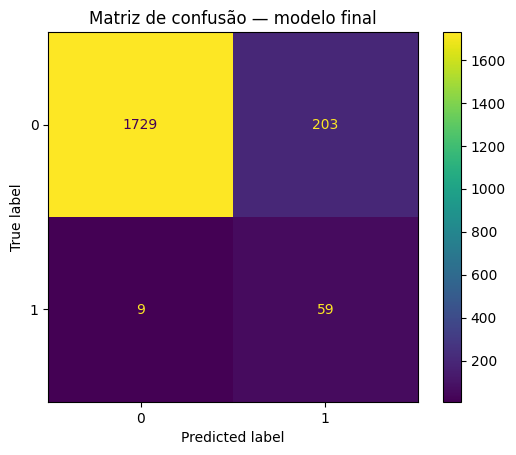

In [ ]:
# === Avaliação final ===

# Verifica se foi feita uma busca de hiperparâmetros
# e se essa busca possui o atributo best_estimator_,
# que representa o melhor modelo encontrado.
if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"

# Caso não exista modelo otimizado, mas existam modelos treinados,
# escolhe um modelo da lista de modelos candidatos.
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]

# Caso não exista modelo otimizado nem modelos treinados,
# nenhum modelo final é selecionado.
else:
    final_model = None
    final_model_name = None

# Exibe o nome do modelo escolhido para avaliação final.
print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test) # Previsão usando dados de teste

    y_pred_proba = final_model.predict_proba(X_test)[:, 1] # Probabilidade de predição para a classe positiva
    roc_auc = roc_auc_score(y_test, y_pred_proba) # Mudança: inclusão dessa métrica para padronizar com o retorno do tópico 8

    print(classification_report(y_test, y_pred)) # Exibe as métricas de classificação (precision, recall. f1-score e support) para os dados de TESTE
    print(f"ROC-AUC: {roc_auc:.4f}")
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test) # Gera a matriz de confusão, mostrando os acertos e erros do modelo para cada classe.
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


In [ ]:
# === Mudança: código para Ajudar na respota do "Há sinais de overfitting ou underfitting?  ===
# Avaliação no conjunto de treinamento
y_pred_train = final_model.predict(X_train)

print("=== Treinamento ===")
print(classification_report(y_train, y_pred_train))

# Avaliação no conjunto de teste
y_pred_test = final_model.predict(X_test)

print("=== Teste (Resultados do Tópico Anterior) ===")
print(classification_report(y_test, y_pred_test))

=== Treinamento ===
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      7729
           1       0.22      0.87      0.35       271

    accuracy                           0.89      8000
   macro avg       0.61      0.88      0.65      8000
weighted avg       0.97      0.89      0.92      8000

=== Teste (Resultados do Tópico Anterior) ===
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1932
           1       0.23      0.87      0.36        68

    accuracy                           0.89      2000
   macro avg       0.61      0.88      0.65      2000
weighted avg       0.97      0.89      0.92      2000



## 10.1 Análise de erros e limitações

**Quais tipos de erro o modelo comete mais?**

O modelo apresenta mais falsos positivos do que falsos negativos. O alto recall da classe de falha (0,87) indica que a maior parte das máquinas que realmente apresentam falha é identificada. Em contrapartida, a precisão (0,23) mostra que muitas máquinas saudáveis são classificadas incorretamente como falha. Esse comportamento é compatível com o objetivo da otimização, que priorizou a redução de falhas não detectadas, mesmo ao custo de aumentar número de manutenções preditivas em máquinas boas.

**Há sinais de overfitting ou underfitting?**

Não há evidências de overfitting nem de underfitting. O desempenho obtido nos conjuntos de treinamento e teste é muito semelhante, tanto para a classe majoritária quanto para a classe de falha. Essa consistência indica que o modelo conseguiu generalizar adequadamente para dados não vistos.

**A métrica escolhida captura bem o objetivo do problema?**

Sim. Como o objetivo é identificar máquinas com falha, o recall é uma métrica adequada. Entretanto, sua análise deve ser complementada por métricas como precision e F1-score, uma vez que o aumento do recall pode ocorrer à custa de um maior número de falsos positivos, como observado neste trabalho.

**Há viés, limitação de dados ou risco de generalização?**

Sim. A avaliação foi realizada em um único conjunto de dados, recomenda-se validar o modelo em dados provenientes de outros equipamentos ou condições operacionais antes de sua utilização em ambiente real.

**Em quais cenários o modelo não deveria ser usado?**

O modelo não deve ser utilizado de forma isolada em cenários nos quais um grande número de falsos alarmes gere impactos operacionais ou custos elevados. Como a otimização priorizou o recall, o modelo tende a classificar mais máquinas saudáveis como falha, sendo recomendável utilizá-lo em conjunto com inspeções ou análises complementares antes da tomada de decisão.

**Comparação com o baseline**

Em relação ao baseline, o modelo final otimizado apresentou melhora significativa na capacidade de identificar falhas, elevando o recall da classe de falha de 0,00 para 0,87. Quando comparado ao Random Forest antes da otimização, observou-se um aumento expressivo do recall (de 0,49 para 0,87), objetivo principal da otimização. Em contrapartida, houve redução na precisão, na acurácia, no F1-score ponderado e no ROC-AUC, evidenciando o compromisso entre identificar mais falhas reais e aumentar a quantidade de falsos positivos. Considerando o contexto de manutenção preditiva, essa troca pode ser considerada aceitável, pois deixar de detectar uma falha tende a ser mais crítico do que investigar um alarme falso.

| Métrica            | Baseline | Random Forest | Random Forest Otimizado |
| :----------------- | -------: | ------------: | ----------------------: |
| Acurácia           |   0,9660 |    **0,9805** |                  0,8900 |
| Precisão           |   0,0000 |    **0,8919** |                  0,2300 |
| Recall             |   0,0000 |        0,4853 |              **0,8700** |
| F1-score ponderado |   0,9493 |    **0,9777** |                  0,9200 |
| ROC-AUC            |   0,5000 |    **0,9653** |                  0,9419 |





# 11. Comparação final dos modelos

Abaixo síntese comparativa.

| Modelo                               | **Recall (métrica principal)** | Precisão |   Acurácia | F1 ponderado |    ROC AUC | Observações                                                                                                                                                                                                        |
| ------------------------------------ | -----------------------------: | -------: | ---------: | -----------: | ---------: | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Baseline                             |                         0,0000 |   0,0000 |     0,9660 |       0,9493 |     0,5000 | Não identificou nenhum caso de falha, classificando todas as amostras como classe majoritária. Utilizado apenas como referência de desempenho.                                                                     |
| Modelo 1 – Regressão Logística       |                         0,1029 |   0,6364 |     0,9675 |       0,9560 |     0,8994 | Melhorou em relação ao baseline, mas apresentou baixa capacidade de identificar falhas.                                                                                                                            |
| Modelo 2 – Random Forest             |                         0,4853 |   0,8919 | **0,9805** |   **0,9777** | **0,9653** | Apresentou o melhor desempenho geral antes da otimização, com alta precisão e excelente equilíbrio entre as métricas.                                                                                              |
| **Modelo otimizado – Random Forest** |                     **0,8700** |   0,2300 |     0,8900 |       0,9200 |     0,9419 | A otimização priorizou o recall, aumentando significativamente a detecção de falhas. Em contrapartida, houve redução da precisão, da acurácia, do F1 ponderado e do ROC AUC devido ao aumento de falsos positivos. |



# 12. Boas práticas e rastreabilidade

| Decisão                                                           | Justificativa                                                                                                                                                     | Impacto esperado                                                                                             |
| ----------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------ |
| Utilizar seed = 42                          | Garantir a reprodutibilidade da divisão dos dados e do treinamento dos modelos.                                                                                   | Obter resultados consistentes em diferentes execuções.                                                       |
| Dividir os dados em treino (80%) e teste (20%) com estratificação | Preservar a proporção entre as classes devido ao desbalanceamento do target.                                                                               | Tornar a avaliação do modelo mais representativa.              |
| Remover UDI e Product ID                                  | São identificadores sem relação direta com a ocorrência de falhas.                                                                                                | Evitar que o modelo aprenda padrões irrelevantes.                                                            |
| Remover as variáveis TWF, HDF, PWF, OSF e RNF | Essas variáveis representam tipos específicos de falha cuja combinação define a variável target (Machine failure). Mantê-las poderia causar vazamento de dados. | Evitar desempenho artificialmente elevado e garantir uma avaliação realista do modelo.                       |
| Utilizar DummyClassifier como baseline                        | Estabelecer uma referência mínima de desempenho para comparação com os demais modelos.                                                                            | Verificar se os modelos realmente aprenderam padrões dos dados.                                              |
| Testar Regressão Logística e Random Forest                | Comparar uma abordagem linear e interpretável com outra capaz de capturar relações não lineares.                                                                  | Identificar o modelo mais adequado ao problema.                                                              |
| Utilizar class_weight = balanced no Random Forest otimizado | Reduzir o impacto do desbalanceamento entre as classes durante o treinamento.                                                                                     | Aumentar a capacidade de identificar falhas da classe minoritária.                                           |
| Definir o recall como principal critério de otimização        | Em manutenção preditiva, deixar de detectar uma falha é mais crítico do que gerar falsos alarmes.                                                                 | Maximizar a identificação de falhas reais.                                                                   |




# 13. Conclusão

O objetivo deste trabalho foi desenvolver um modelo de Machine Learning capaz de prever falhas em equipamentos industriais a partir de variáveis operacionais, contribuindo para a manutenção preditiva e reduzindo o risco de paradas não planejadas.

Foram avaliadas diferentes abordagens, utilizando um DummyClassifier como baseline e os modelos de Regressão Logística e Random Forest como candidatos. O Random Forest apresentou o melhor desempenho geral e, após a otimização de hiperparâmetros, obteve um recall de aproximadamente 87%, tornando-se a solução mais adequada para o objetivo proposto. Em comparação com o baseline, que não foi capaz de identificar nenhum caso de falha, o modelo otimizado demonstrou elevada capacidade de detectar a classe minoritária, aspecto essencial em aplicações de manutenção preditiva.

Um dos principais aprendizados deste trabalho foi compreender que a escolha da métrica de otimização influencia diretamente o comportamento do modelo. Inicialmente, a busca pelos melhores hiperparâmetros foi realizada utilizando o F1-score ponderado e sem o uso do parâmetro class_weight='balanced, resultando em um modelo com recall próximo de 50%. Embora apresentasse melhor equilíbrio entre as métricas, esse desempenho ainda significava que aproximadamente metade das falhas reais deixava de ser identificada. Diante desse resultado, a estratégia foi revista, passando a utilizar o recall como principal critério de otimização e o parâmetro class_weight='balanced, priorizando a identificação da classe minoritária.

Essa alteração aumentou significativamente a capacidade de detectar falhas, porém reduziu a precisão do modelo, elevando a quantidade de falsos positivos. Ainda assim, considerando o contexto da manutenção preditiva, essa foi considerada uma troca aceitável, pois o custo de realizar algumas inspeções ou manutenções preventivas desnecessárias tende a ser menor do que o impacto de deixar de identificar uma falha real, que pode resultar em paradas não planejadas, danos ao equipamento e custos operacionais elevados.

Como limitações, destaca-se que o modelo foi treinado e avaliado utilizando apenas um conjunto de dados e um único cenário operacional, não sendo possível garantir que o mesmo desempenho será obtido em equipamentos ou condições diferentes. Além disso, a otimização de hiperparâmetros foi realizada em um espaço reduzido de busca e não foram avaliadas técnicas adicionais de tratamento do desbalanceamento, como métodos de reamostragem.

Como trabalhos futuros, recomenda-se validar o modelo em bases de dados provenientes de outros equipamentos, ampliar a busca por hiperparâmetros, testar algoritmos adicionais e comparar estratégias de balanceamento das classes. Essas melhorias podem contribuir para aumentar a robustez e a capacidade de generalização do modelo em aplicações reais.

